In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import pandas as pd

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

class exercise

In [2]:
# load SST data

sst = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
sst = sst.sel(time = slice('1960', '2020')) 
sst.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 732, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2020-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [3]:
#make anomaly
sst_clim = sst.sst.groupby('time.month').mean(dim='time')
sst_anom = sst.sst.groupby('time.month') - sst_clim

In [4]:
#detrend
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

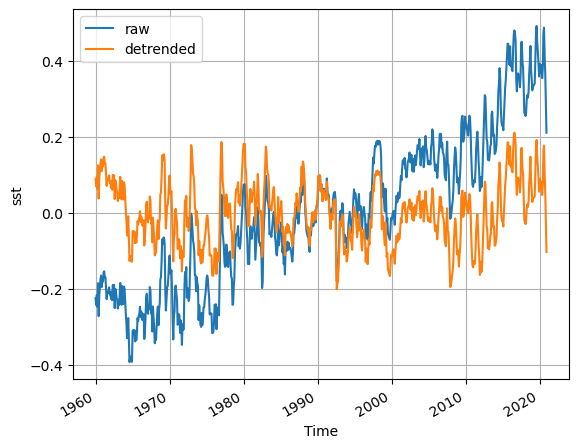

In [5]:
sst_anom.mean(dim=['lon', 'lat']).plot(label='raw')
sst_anom_detrended.mean(dim=['lon', 'lat']).plot(label='detrended')
plt.grid()
plt.legend()

In [6]:
ds_raw=sst_anom.mean(dim=['lon', 'lat'])
ds_detrend=sst_anom_detrended.mean(dim=['lon', 'lat'])

xtime=sst_anom['time']
nt=len(xtime)
xts=np.arange(0, nt, 1)
ds_raw

<xarray.DataArray 'sst' (time: 732)>
array([-2.24409580e-01, -2.42298543e-01, -2.16344059e-01, -2.47331142e-01,
       -1.84645504e-01, -2.71243662e-01, -2.16660187e-01, -1.94516748e-01,
       -1.74407989e-01, -1.64716750e-01, -1.94846973e-01, -1.74885005e-01,
       -1.80657402e-01, -1.56256661e-01, -1.53432116e-01, -1.70437187e-01,
       -1.68780640e-01, -1.97083116e-01, -2.26792380e-01, -2.07946628e-01,
       -2.09983736e-01, -2.03688025e-01, -1.95821419e-01, -2.14361116e-01,
       -2.10269973e-01, -2.26102993e-01, -2.06876338e-01, -2.29313970e-01,
       -1.89333603e-01, -2.10955545e-01, -1.89078078e-01, -2.50221044e-01,
       -1.99809864e-01, -2.04868197e-01, -2.23729417e-01, -2.26551384e-01,
       -2.51156479e-01, -2.38733932e-01, -2.41838574e-01, -2.19220579e-01,
       -1.84088439e-01, -2.01111257e-01, -2.41530851e-01, -1.92326248e-01,
       -2.31833279e-01, -2.39369616e-01, -1.93503976e-01, -1.98824301e-01,
       -2.33404323e-01, -2.65594155e-01, -2.88016140e-01, -3.29185218e-01,
       -3.03883582e-01, -2.76473880e-01, -3.32000792e-01, -3.91828328e-01,
       -3.80047858e-01, -3.77475679e-01, -3.90760988e-01, -3.91114563e-01,
       -3.10461372e-01, -3.08150083e-01, -3.18823248e-01, -3.07974428e-01,
       -3.37790251e-01, -3.11166167e-01, -3.34719062e-01, -3.15477043e-01,
       -2.76608348e-01, -2.84166843e-01, -2.69584119e-01, -2.64822632e-01,
       -2.46801957e-01, -2.74150848e-01, -2.59079278e-01, -2.63432562e-01,
       -2.81620085e-01, -2.76166856e-01, -2.65948474e-01, -3.31127852e-01,
...
        3.50939333e-01,  2.77713835e-01,  2.39771202e-01,  2.29747057e-01,
        2.30482563e-01,  2.16975406e-01,  2.50400215e-01,  2.89661884e-01,
        3.27539355e-01,  3.47709924e-01,  3.80688697e-01,  4.10689026e-01,
        4.44420636e-01,  4.43732023e-01,  4.06604439e-01,  3.88743520e-01,
        4.37288165e-01,  3.85421246e-01,  3.94434720e-01,  3.74459416e-01,
        3.72200519e-01,  4.33451891e-01,  4.67310131e-01,  4.78949368e-01,
        4.69936520e-01,  4.49018776e-01,  3.49870831e-01,  3.18933129e-01,
        3.62259418e-01,  3.66297215e-01,  3.58876050e-01,  3.54560077e-01,
        3.29826862e-01,  3.60142171e-01,  4.46510315e-01,  4.49392825e-01,
        3.95705730e-01,  3.83564085e-01,  3.31541181e-01,  2.63718247e-01,
        2.60144949e-01,  2.54341483e-01,  2.63286740e-01,  2.96775281e-01,
        3.08491975e-01,  3.02630454e-01,  3.18407178e-01,  3.64980191e-01,
        3.97090912e-01,  4.38134670e-01,  3.77211750e-01,  3.53434563e-01,
        3.21725786e-01,  3.30406755e-01,  3.33467513e-01,  3.37047458e-01,
        3.39803666e-01,  4.10906136e-01,  4.67224509e-01,  4.90527451e-01,
        4.45940584e-01,  4.24517661e-01,  3.94186378e-01,  3.58142078e-01,
        3.91344965e-01,  3.66664559e-01,  3.77533346e-01,  3.87927413e-01,
        3.53873312e-01,  3.78786504e-01,  4.71776962e-01,  4.86141652e-01,
        4.14439559e-01,  3.65402520e-01,  2.83588588e-01,  2.10370749e-01],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2020-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [7]:
import numpy as np

comX=[xts,ds_raw]
X1=np.transpose(comX)

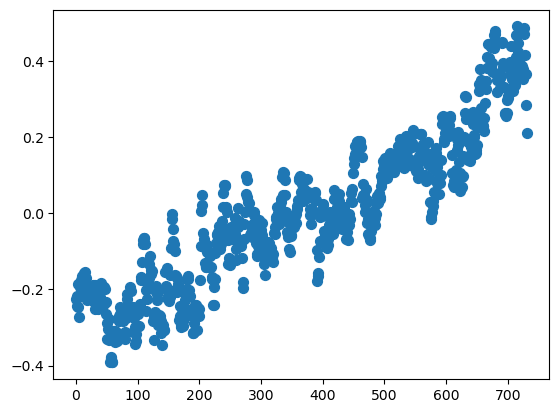

In [8]:
plt.scatter(X1[:,0],X1[:,1],s=50)

In [9]:
from sklearn.cluster import KMeans

In [10]:
km1 = KMeans(3)
km1.fit(X1)

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


KMeans(n_clusters=3)

In [16]:
# load precipitation data
prec = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\precip.mon.mean.nc")
prec = prec.sel(time = slice('1979', '2019')) 
prec.load()

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 492, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1979-01-01 1979-02-01 ... 2020-01-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.1305 0.1327 0.1341
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2023/01 through latest.

In [17]:
#prec_ta = prec.sel(lat = slice(10,30), lon = slice(100,140))
#prec_ta_mean = prec_ta.mean(dim = ['lon', 'lat'])
#prec_ta_mean

In [19]:
ds_climo = prec.groupby('time.month').mean()
ds_anoms = prec.groupby('time.month')-ds_climo
ds_anoms

<xarray.Dataset>
Dimensions:   (lat: 72, lon: 144, time: 492, nv: 2)
Coordinates:
  * lat       (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon       (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time      (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month     (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nv
Data variables:
    lat_bnds  (time, lat, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon_bnds  (time, lon, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precip    (time, lat, lon) float32 -0.02191 -0.03154 ... -0.2816 -0.2292

In [22]:
#select domain
latS = 10
latN = 30
lonL = 100
lonR = 140
ds_anoms_TP = ds_anoms.sel(lat = slice(latS, latN), lon = slice(lonL, lonR))

nt = len(ds_anoms_TP['time'])
ny = len(ds_anoms_TP['lat'])
nx = len(ds_anoms_TP['lon'])
print(nt, ny, nx)
data = ds_anoms_TP['precip'].values
ds_anoms_2d = np.reshape(data, [nt, ny*nx],order='F')
mk2 = KMeans(n_clusters = 4).fit(ds_anoms_2d)

492 8 16


c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [23]:
def get_cluster_fraction(m, label):        
        return (m.labels_==label).sum()/(m.labels_.size*1.0)

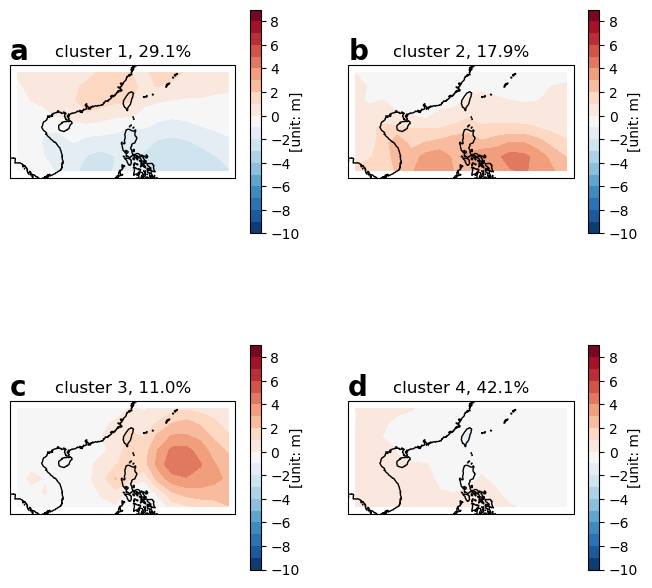

In [25]:
x,y = np.meshgrid(ds_anoms_TP.lon, ds_anoms_TP.lat)
proj = ccrs.PlateCarree(central_longitude = 180)
fig, axes = plt.subplots(2,2, figsize = (8,8), subplot_kw = dict(projection = proj))
regimes = ['cluster 1', 'cluster 2', 'cluster 3', 'cluster 4']
tags = list('abcd')
for i in range(mk2.n_clusters):
    onecen = mk2.cluster_centers_[i,:].reshape(ny,nx, order = 'F')
    cs = axes.flat[i].contourf(x, y, onecen,
                               levels = np.arange(-10, 10, 1), 
                               transform = ccrs.PlateCarree(),
                               cmap = 'RdBu_r')
    
    cb=fig.colorbar(cs, ax = axes.flat[i], shrink = 0.8, aspect = 20) 
    cb.set_label('[unit: m]',labelpad = -7)    
    axes.flat[i].coastlines()
    axes.flat[i].set_global()
    axes.flat[i].set_extent([lonL, lonR, latS, latN],crs=ccrs.PlateCarree())

    title = '{}, {:4.1f}%'.format(regimes[i], get_cluster_fraction(mk2, i)*100)
    axes.flat[i].set_title(title)
    plt.text(0, 1, tags[i], 
             transform=axes.flat[i].transAxes, 
             va='bottom', 
             fontsize=plt.rcParams['font.size']*2, 
             fontweight='bold')

In [50]:
# load temperature data
temp = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\air.mon.mean.nc")
temp = temp.sel(time = slice('1980', '2020')) 
temp.load()

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 492)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
Data variables:
    air      (time, lat, lon) float32 -26.17 -26.17 -26.17 ... -22.16 -22.16
Attributes:
    description:    Data from NCEP initialized reanalysis (4x/day).  These ar...
    platform:       Model
    Conventions:    COARDS
    NCO:            20121012
    history:        Thu May  4 20:11:16 2000: ncrcat -d time,0,623 /Datasets/...
    title:          monthly mean air.sig995 from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [51]:
ds_climo = temp.groupby('time.month').mean()
ds_anoms = temp.groupby('time.month')-ds_climo
ds_anoms

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 492)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    air      (time, lat, lon) float32 2.491 2.491 2.491 ... 0.9349 0.9349 0.9349

In [49]:
#select domain
latS = 10
latN = 30
lonL = 100
lonR = 140
ds_anoms_TP = ds_anoms.sel(lat = slice(latS, latN), lon = slice(lonL, lonR))

nt = len(ds_anoms_TP['time'])
ny = len(ds_anoms_TP['lat'])
nx = len(ds_anoms_TP['lon'])
print(nt, ny, nx)
#data = ds_anoms_TP['air'].values
#ds_anoms_2d = np.reshape(data, [nt, ny*nx],order='F')
#mk2 = KMeans(n_clusters = 4).fit(ds_anoms_2d)

492 0 17


In [52]:
ds_anoms_TP

<xarray.Dataset>
Dimensions:  (lat: 0, lon: 17, time: 492)
Coordinates:
  * lat      (lat) float32 
  * lon      (lon) float32 100.0 102.5 105.0 107.5 ... 132.5 135.0 137.5 140.0
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    air      (time, lat, lon) float32

In [41]:
def get_cluster_fraction(m, label):        
        return (m.labels_==label).sum()/(m.labels_.size*1.0)

TypeError: Shapes of x (0, 81) and z (73, 144) do not match

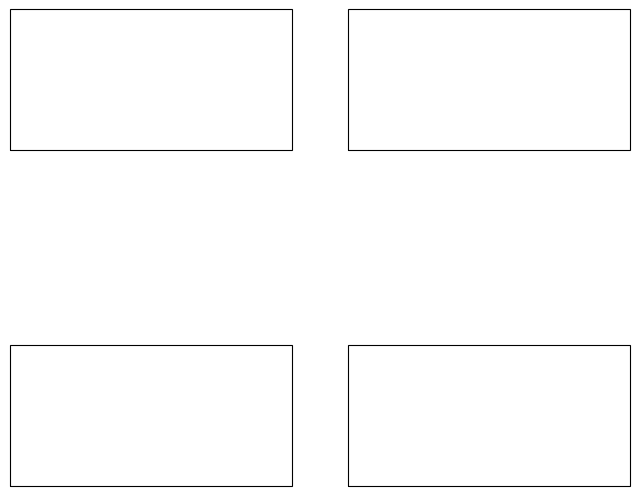

In [42]:
x,y = np.meshgrid(ds_anoms_TP.lon, ds_anoms_TP.lat)
proj = ccrs.PlateCarree(central_longitude=180)
fig, axes = plt.subplots(2,2, figsize=(8,8), subplot_kw=dict(projection=proj))
regimes = ['cluster 1', 'cluster 2', 'cluster 3', 'cluster 4']
tags = list('abcd')
for i in range(mk2.n_clusters):
    onecen = mk2.cluster_centers_[i,:].reshape(ny,nx, order='F')
    cs = axes.flat[i].contourf(x, y, onecen,
                               levels=np.arange(-10, 10, 1), 
                               transform=ccrs.PlateCarree(),
                               cmap='RdBu_r')
    
    cb=fig.colorbar(cs, ax=axes.flat[i], shrink=0.8, aspect=20) 
    cb.set_label('[unit: m]',labelpad=-7)    
    axes.flat[i].coastlines()
    axes.flat[i].set_global()
    axes.flat[i].set_extent([lonL, lonR, latS, latN],crs=ccrs.PlateCarree())

    title = '{}, {:4.1f}%'.format(regimes[i], get_cluster_fraction(mk2, i)*100)
    axes.flat[i].set_title(title)
    plt.text(0, 1, tags[i], 
             transform=axes.flat[i].transAxes, 
             va='bottom', 
             fontsize=plt.rcParams['font.size']*2, 
             fontweight='bold')

In [16]:
#read precipitation
url = 'http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/gpcp/precip.mon.mean.nc'
ds_prec = xr.open_dataset(url)
ds_prec = ds_prec.sel(time=slice('1979', '2019'))
ds_prec.load()
ds_prec

In [ ]:
ds_climo=ds_prec.groupby('time.month').mean()
ds_anoms=ds_prec.groupby('time.month')-ds_climo
ds_anoms

<xarray.Dataset>
Dimensions:   (lat: 72, lon: 144, time: 492, nv: 2)
Coordinates:
  * lat       (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon       (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time      (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month     (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nv
Data variables:
    lat_bnds  (time, lat, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon_bnds  (time, lon, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precip    (time, lat, lon) float32 -0.02191 -0.03154 ... -0.2816 -0.2292

In [ ]:
#select domain
latS=-30
latN=30
lonL=100
lonR=300
ds_anoms_TP = ds_anoms.sel(lat=slice(latS, latN), lon=slice(lonL, lonR))

nt = len(ds_anoms_TP['time'])
ny = len(ds_anoms_TP['lat'])
nx = len(ds_anoms_TP['lon'])
print(nt, ny, nx)
data = ds_anoms_TP['precip'].values
ds_anoms_2d = np.reshape(data, [nt, ny*nx],order='F')
mk2 = KMeans(n_clusters=4).fit(ds_anoms_2d)

492 24 80


c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [ ]:
def get_cluster_fraction(m, label):        
        return (m.labels_==label).sum()/(m.labels_.size*1.0)

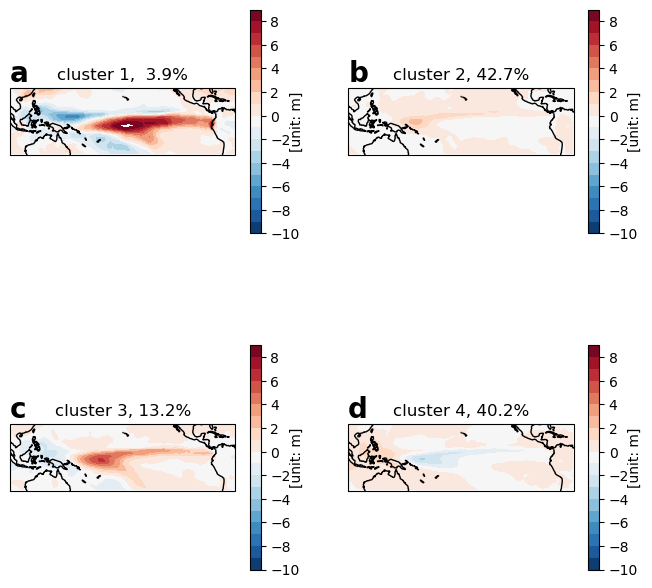

In [ ]:
x,y = np.meshgrid(ds_anoms_TP.lon, ds_anoms_TP.lat)
proj = ccrs.PlateCarree(central_longitude=180)
fig, axes = plt.subplots(2,2, figsize=(8,8), subplot_kw=dict(projection=proj))
regimes = ['cluster 1', 'cluster 2', 'cluster 3', 'cluster 4']
tags = list('abcd')
for i in range(mk2.n_clusters):
    onecen = mk2.cluster_centers_[i,:].reshape(ny,nx, order='F')
    cs = axes.flat[i].contourf(x, y, onecen,
                               levels=np.arange(-10, 10, 1), 
                               transform=ccrs.PlateCarree(),
                               cmap='RdBu_r')
    
    cb=fig.colorbar(cs, ax=axes.flat[i], shrink=0.8, aspect=20) 
    cb.set_label('[unit: m]',labelpad=-7)    
    axes.flat[i].coastlines()
    axes.flat[i].set_global()
    axes.flat[i].set_extent([lonL, lonR, latS, latN],crs=ccrs.PlateCarree())

    title = '{}, {:4.1f}%'.format(regimes[i], get_cluster_fraction(mk2, i)*100)
    axes.flat[i].set_title(title)
    plt.text(0, 1, tags[i], 
             transform=axes.flat[i].transAxes, 
             va='bottom', 
             fontsize=plt.rcParams['font.size']*2, 
             fontweight='bold')